In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
from scipy.stats import gaussian_kde

# ======================================================================
# 1. Environment & Path Setup
# ======================================================================
sys.path.append('/scratch/users/linyao/ML4MJO/scripts/src')
sys.path.append('/scratch/users/linyao/ML4MJO/scripts/src/utils')
import metrics as mjo

# Fig 2

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================================================================
# 1. Configuration & Setup
# ======================================================================
# Fixed parameters for reconstructing the exp_name
dataflg = os.environ.get("dataflg", "era5").lower()
input_var_name = os.environ.get("input_var", "olr")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")
reload_model = os.environ.get("reload_model", "fltano120")
best_expflg = os.environ.get("best_expflg", "BEST")

# Multi-lead toggles
multi_lead = os.environ.get("multi_lead", "true").lower() == "true"
max_lead = int(os.environ.get("max_lead", 35))  # Used for concatenating single leads

# Assuming we are plotting Trial 1 based on your previous TOP_TRIALS = [1,]
trial_tag = "t1"
PERIODS = ["test"]

# Base directory where your previous script saved the metrics
metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")

# Directory to save these new combined comparison plots
save_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs") / "FigS"
save_dir.mkdir(parents=True, exist_ok=True)


# ======================================================================
# 2. Helper: Load metrics for a given experiment flag
# ======================================================================
def load_best_metrics(period_name):
    """Load BCC/RMSE metrics for the BEST experiment.
    BEST naming: {dataflg}_BEST_{model_name}_{output_var_name}
    Returns (leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse) or None."""
    best_exp_name = f"{dataflg}_{best_expflg}_{model_name}_{output_var_name}"

    if multi_lead:
        data_path = metrics_base_dir / best_exp_name / f"metrics_{best_exp_name}_{trial_tag}_{period_name}.npz"
        if not data_path.exists():
            print(f"     [Warning] Missing BEST data: {data_path}. Skipping line.")
            return None
        data = np.load(data_path)
        lead_max = int(data['lead'])
        leads = np.arange(0, lead_max + 1)
        return leads, data['ens_bcc'], data['ind_bcc'], data['ens_rmse'], data['ind_rmse']
    else:
        ens_bcc_list = []
        ind_bcc_list = []
        ens_rmse_list = []
        ind_rmse_list = []
        leads_avail = []

        for l in range(max_lead + 1):
            best_exp_lead = f"{best_exp_name}_lead{l}"
            data_path = metrics_base_dir / best_exp_lead / f"metrics_{best_exp_lead}_{trial_tag}_{period_name}.npz"
            if data_path.exists():
                data = np.load(data_path)
                ens_bcc_list.append(data['ens_bcc'])
                ens_rmse_list.append(data['ens_rmse'])
                ind_bcc_list.append(data['ind_bcc'])
                ind_rmse_list.append(data['ind_rmse'])
                leads_avail.append(l)

        if not leads_avail:
            print(f"     [Warning] No single-lead BEST data found. Skipping line.")
            return None

        leads = np.array(leads_avail)
        ens_bcc = np.array(ens_bcc_list)
        ens_rmse = np.array(ens_rmse_list)
        ind_bcc = np.array(ind_bcc_list).T
        ind_rmse = np.array(ind_rmse_list).T
        return leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse


# ======================================================================
# 3. Plotting Loop
# ======================================================================
print("\n" + "="*50)
print("=== GENERATING MULTI-EXPERIMENT PLOTS WITH RELOAD ===")
print("="*50)

# Slightly smaller font to accommodate the longer legend labels
plt.rcParams['font.size'] = 22

for period_name in PERIODS:
    print(f"  -> Generating plots for period: {period_name.upper()}")

    fig_bcc, ax_bcc = plt.subplots(1, 1, figsize=(8.5, 6.5))
    fig_rmse, ax_rmse = plt.subplots(1, 1, figsize=(8.5, 6.5))

    # --- Plot BEST baseline (solid blue line) ---
    best_result = load_best_metrics(period_name)
    if best_result is not None:
        leads_b, ens_bcc_b, ind_bcc_b, ens_rmse_b, ind_rmse_b = best_result
        bcc_min_b, bcc_max_b = np.min(ind_bcc_b, axis=0), np.max(ind_bcc_b, axis=0)
        rmse_min_b, rmse_max_b = np.min(ind_rmse_b, axis=0), np.max(ind_rmse_b, axis=0)

        ax_bcc.fill_between(leads_b, bcc_min_b, bcc_max_b, color='tab:blue', alpha=0.15)
        ax_bcc.plot(leads_b, ens_bcc_b, '-o', color='tab:blue', linewidth=2, label='BEST')

        ax_rmse.fill_between(leads_b, rmse_min_b, rmse_max_b, color='tab:blue', alpha=0.15)
        ax_rmse.plot(leads_b, ens_rmse_b, '-o', color='tab:blue', linewidth=2, label='BEST')

    # --- Formatting BCC Plot ---
    ax_bcc.axhline(y=0.5, color='black', linestyle='--', linewidth=2)
    ax_bcc.set_xticks(np.arange(0, 41, 5))
    ax_bcc.set_xlim(0, 35)
    ax_bcc.set_ylim(0.1, 1.0)
    ax_bcc.set_yticks(np.arange(0.1, 1.1, 0.2))
    ax_bcc.set_xlabel('Forecast lead (days)')
    ax_bcc.set_ylabel('BCC')
    ax_bcc.grid(True, linestyle=':', alpha=0.6)

    fig_bcc.tight_layout()
    if multi_lead:
        bcc_save_path = save_dir / f"plot_bcc_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_multi.png"
    else:
        bcc_save_path = save_dir / f"plot_bcc_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_single.png"

    fig_bcc.savefig(bcc_save_path, dpi=300)

    # --- Formatting RMSE Plot ---
    # ax_rmse.axhline(y=1.2, color='black', linestyle='--', linewidth=2)
    # ax_rmse.axhline(y=np.sqrt(2), color='gray', linestyle='-.', linewidth=2)
    ax_rmse.set_xticks(np.arange(0, 41, 5))
    ax_rmse.set_xlim(0, 35)
    ax_rmse.set_ylim(0, 1.8)
    ax_rmse.set_xlabel('Forecast lead (days)')
    ax_rmse.set_ylabel('RMSE')
    ax_rmse.grid(True, linestyle=':', alpha=0.6)

    fig_rmse.tight_layout()
    if multi_lead:
        rmse_save_path = save_dir / f"plot_rmse_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_BEST_{period_name}_multi.png"
    else:
        rmse_save_path = save_dir / f"plot_rmse_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_BEST_{period_name}_single.png"

    fig_rmse.savefig(rmse_save_path, dpi=300)

    # Close figures to prevent memory leaks in the loop
    plt.close(fig_bcc)
    plt.close(fig_rmse)

print(f"\nAll comparative plots generated and saved successfully to:\n{save_dir}")



=== GENERATING MULTI-EXPERIMENT PLOTS WITH RELOAD ===
  -> Generating plots for period: TEST

All comparative plots generated and saved successfully to:
/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS


# Fig S; bcc for BEST from single lead

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================================================================
# 1. Configuration & Setup
# ======================================================================
dataflg = os.environ.get("dataflg", "era5").lower()
model_name = os.environ.get("model_name", "UNet_A")
best_expflg = "BEST"
trial_tag = "t1"
PERIODS = ["test"]
max_lead = int(os.environ.get("max_lead", 35))

# Color Mapping as requested
TARGET_COLORS = {'RMM': 'orange', 'ROMI': 'red'}
metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")
save_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS")
save_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.size'] = 22

# Explicit Box Layout (consistent with your previous plotting preferences)
MAIN_AX_BOX = [0.15, 0.2, 0.8, 0.7]
STANDARD_FIGSIZE = (8.5, 6.5)

# ======================================================================
# 2. Loading Helpers
# ======================================================================
def load_best_metrics(target_var, period_name):
    """Concatenates single-lead metrics for a specific target variable from the BEST experiment."""
    ens_bcc_list, ind_bcc_list = [], []
    ens_rmse_list, ind_rmse_list = [], []
    leads_avail = []

    # BEST naming convention: e.g., era5_BEST_UNet_A_RMM
    best_exp_name = f"{dataflg}_{best_expflg}_{model_name}_{target_var}"

    for l in range(max_lead + 1):
        best_exp_lead = f"{best_exp_name}_lead{l}"
        data_path = metrics_base_dir / best_exp_lead / f"metrics_{best_exp_lead}_{trial_tag}_{period_name}.npz"
        
        if data_path.exists():
            data = np.load(data_path)
            ens_bcc_list.append(data['ens_bcc'])
            ind_bcc_list.append(data['ind_bcc'])
            ens_rmse_list.append(data['ens_rmse'])
            ind_rmse_list.append(data['ind_rmse'])
            leads_avail.append(l)

    if not leads_avail:
        return None

    return {
        'leads': np.array(leads_avail),
        'ens_bcc': np.array(ens_bcc_list),
        'ind_bcc': np.array(ind_bcc_list).T, # (N_Ensembles, Leads)
        'ens_rmse': np.array(ens_rmse_list),
        'ind_rmse': np.array(ind_rmse_list).T
    }

def load_noaa_metrics(target_var, period_name):
    """Concatenates single-lead metrics for a specific target variable replacing dataflg with 'noaa'."""
    ens_bcc_list = []
    ens_rmse_list = []
    leads_avail = []

    # NOAA naming convention: e.g., noaa_BEST_UNet_A_RMM
    noaa_exp_name = f"noaa_{best_expflg}_{model_name}_{target_var}"

    for l in range(max_lead + 1):
        noaa_exp_lead = f"{noaa_exp_name}_lead{l}"
        data_path = metrics_base_dir / noaa_exp_lead / f"metrics_{noaa_exp_lead}_{trial_tag}_{period_name}.npz"
        
        if data_path.exists():
            data = np.load(data_path)
            ens_bcc_list.append(data['ens_bcc'])
            ens_rmse_list.append(data['ens_rmse'])
            leads_avail.append(l)

    if not leads_avail:
        return None

    return {
        'leads': np.array(leads_avail),
        'ens_bcc': np.array(ens_bcc_list),
        'ens_rmse': np.array(ens_rmse_list)
    }

# ======================================================================
# 3. Main Plotting Loop (BEST & NOAA)
# ======================================================================
for period in PERIODS:
    print(f"Plotting RMM vs ROMI for BEST & NOAA ({period})...")

    fig_bcc, ax_bcc= plt.subplots(1,1, figsize=STANDARD_FIGSIZE)

    fig_rmse, ax_rmse = plt.subplots(1,1, figsize=STANDARD_FIGSIZE)

    for target in ['RMM', 'ROMI']:
        res_best = load_best_metrics(target, period)
        res_noaa = load_noaa_metrics(target, period)
        color = TARGET_COLORS[target]
        
        if res_best is None:
            print(f"  [Warning] Missing BEST data for {target}. Skipping.")
        else:
            # --- Plot BEST BCC ---
            bcc_min, bcc_max = np.min(res_best['ind_bcc'], axis=0), np.max(res_best['ind_bcc'], axis=0)
            ax_bcc.fill_between(res_best['leads'], bcc_min, bcc_max, color=color, alpha=0.15)
            ax_bcc.plot(res_best['leads'], res_best['ens_bcc'], '-o', color=color, linewidth=2.5, label=f'{target} (BEST)')

            # --- Plot BEST RMSE ---
            rmse_min, rmse_max = np.min(res_best['ind_rmse'], axis=0), np.max(res_best['ind_rmse'], axis=0)
            ax_rmse.fill_between(res_best['leads'], rmse_min, rmse_max, color=color, alpha=0.15)
            ax_rmse.plot(res_best['leads'], res_best['ens_rmse'], '-o', color=color, linewidth=2.5, label=f'{target} (BEST)')

        if res_noaa is None:
            print(f"  [Warning] Missing NOAA data for {target}. Skipping.")
        else:
            # --- Plot NOAA BCC (Dashed, no shading) ---
            ax_bcc.plot(res_noaa['leads'], res_noaa['ens_bcc'], '--', color=color, linewidth=2.5, label=f'{target} (NOAA)')

            # --- Plot NOAA RMSE (Dashed, no shading) ---
            ax_rmse.plot(res_noaa['leads'], res_noaa['ens_rmse'], '--', color=color, linewidth=2.5, label=f'{target} (NOAA)')

    # --- Finalize BCC Plot ---
    ax_bcc.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)
    ax_bcc.set_xlim(0, 35)
    ax_bcc.set_ylim(0.1, 1.0)
    ax_bcc.set_xticks(np.arange(0, 36, 5))
    ax_bcc.set_yticks(np.arange(0.2, 1.1, 0.2))
    ax_bcc.grid(True, linestyle=':', alpha=0.6)

    # --- Finalize RMSE Plot ---
    ax_rmse.set_xlim(0, 35)
    ax_rmse.set_ylim(0, 1.8)
    ax_rmse.set_xticks(np.arange(0, 36, 5))
    ax_rmse.set_yticks(np.arange(0, 1.9, 0.2))
    ax_rmse.grid(True, linestyle=':', alpha=0.6)

    # Save Figures
    fig_bcc.savefig(save_dir / f"bcc_compare_BEST_vs_NOAA_{period}.pdf", dpi=300)
    fig_rmse.savefig(save_dir / f"rmse_compare_BEST_vs_NOAA_{period}.pdf", dpi=300)

    plt.close(fig_bcc)
    plt.close(fig_rmse)

print(f"Plots saved to: {save_dir}")

Plotting RMM vs ROMI for BEST & NOAA (test)...
Plots saved to: /scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS


# 1-1 plots

In [ ]:
import os
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
from scipy.stats import gaussian_kde

# ======================================================================
# 1. Environment & Path Setup
# ======================================================================
sys.path.append('/scratch/users/linyao/ML4MJO/scripts/src')
sys.path.append('/scratch/users/linyao/ML4MJO/scripts/src/utils')
import metrics as mjo

# Read environment variables
dataflg = os.environ.get("dataflg", "era5").lower()
expflg = os.environ.get("expflg", "BEST")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")
multi_lead = os.environ.get("multi_lead", "false").lower() == "true"
plot_lead = 0

import itertools

for dataflg, output_var_name, multi_lead, plot_lead in itertools.product(
    ["era5", "noaa"], 
    ["RMM", "ROMI"], 
    [False, True], 
    [0, 20]
):
    # Determine experiment name and lead time for evaluation
    if not multi_lead:
        lead = plot_lead
        exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}_lead{lead}"
    else:
        exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}"
        lead = plot_lead

    N_TOTAL_ENSEMBLES = 16
    START_DATE = "2016-01-01"
    END_DATE = "2021-12-31"
    TRIAL_RANK = 1
    trial_tag = f"t{TRIAL_RANK}"

    BASE_PRED_PATH = "/scratch/users/linyao/ML4MJO/scripts/outputs/predictions/{dataset_type}/{model_name}/{target_name}/lead{lead_config}/{exp_num}/preds_lr{lr}_bs{batch_size}_do{dropout}_cnn{channels_list_str}_k{kernel_size}_mlp{hidden_layers_str}_{optimizer}.nc"

    # ======================================================================
    # 2. YAML Config Parsing
    # ======================================================================
    config_path = f'/scratch/users/linyao/ML4MJO/scripts/exp/BEST/yaml/best_config_{exp_name}_{trial_tag}.yaml'

    if not os.path.exists(config_path):
        print(f"[Error] Config not found: {config_path}")
        sys.exit(1)
        
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    # Base kwargs for path formatting
    save_kwargs = {
        "dataset_type": exp_name,
        "lead_config": config["data"]["lead"], # The lead used in the directory structure
        "lr": config["training"]["learning_rate"],
        "batch_size": config["training"]["batch_size"],
        "dropout": config["model"]["mlp"]["dropout"],
        "channels_list_str": config["model"]["cnn"]["channels_list_str"],
        "kernel_size": config.get("kernel_size_str", f"{config['model']['cnn']['kernel_size'][0]}_{config['model']['cnn']['kernel_size'][1]}"),
        "hidden_layers_str": config.get("hidden_layers_str", "_".join(map(str, config["model"]["mlp"]["hidden_layers"]))),
        "optimizer": config["training"]["optimizer"],
        "model_name": config["model"]["name"],
        "target_name": config["data"]["target_vars"][0]
    }

    # ======================================================================
    # 3. Data Loading & Processing
    # ======================================================================
    print(f"Loading predictions for {dataflg.upper()} | {model_name} | {output_var_name} | Target Lead: {lead}")

    ensemble_preds = []
    target_data = None

    for exp_num in range(1, N_TOTAL_ENSEMBLES + 1):
        save_kwargs["exp_num"] = f"{trial_tag}/exp{exp_num}"
        fn = BASE_PRED_PATH.format(**save_kwargs)
        
        if not os.path.exists(fn):
            print(f"[Warning] Missing prediction file: {fn}")
            continue
        
        ds = xr.open_dataset(fn).sel(time=slice(START_DATE, END_DATE))
        
        pred_raw = ds['predictions'].values  # Shape: [time, variable]
        ensemble_preds.append(pred_raw)
        
        if target_data is None:
            target_data = ds['targets'].values # Shape: [time, variable]

    if not ensemble_preds:
        print("[Error] No ensemble prediction files found.")
        sys.exit(1)

    # Calculate ensemble mean: Shape [time, variable]
    pred_mean = np.mean(np.stack(ensemble_preds), axis=0)

    # ---------------------------------------------------------
    # Slicing logic for multi_lead (72 vars) vs single_lead (2 vars)
    # ---------------------------------------------------------
    if pred_mean.shape[1] == 72:
        print(f"Detected multi_lead data (72 variables). Slicing for lead {lead}...")
        idx_start = lead * 2
        idx_end = idx_start + 2
        pred_lead = pred_mean[:, idx_start:idx_end].squeeze()
        target_lead = target_data[:, idx_start:idx_end].squeeze()
    else:
        print("Detected single_lead data (2 variables).")
        pred_lead = pred_mean.squeeze()
        target_lead = target_data.squeeze()

    # Calculate phases using the target data (truth)
    phases, amp = mjo.get_phase_amp(
        mjo_ind=output_var_name, 
        datasta=START_DATE, 
        dataend=END_DATE, 
        Fnmjo=config["data"]["target_path"] 
    )
    phases = phases[:pred_mean.shape[0]].squeeze()
    amp = amp[:pred_mean.shape[0]].squeeze()

    # ======================================================================
    # 4. Plotting
    # ======================================================================
    plt.rcParams['font.size'] = 20
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # Colors (matching the target image style)
    color_1st = 'royalblue'  # First mode
    color_2nd = 'orange'     # Second mode
    color_centroid = 'red'   # Mean coordinate dot

    x_grid = np.linspace(-4, 4, 50)

    for phase_idx in range(1, 9):
        ax = axes[phase_idx - 1]
        
        # Mask for the current phase
        mask = (phases == phase_idx) & (amp >=1.0)
        p_pred = pred_lead[mask,:]
        p_true = target_lead[mask,:]
        
        if len(p_pred) == 0:
            continue
            
        # Scatter Plots (Pred on X, Truth on Y)
        ax.plot(p_pred[:, 0], p_true[:, 0], 'o', color=color_1st, markersize=4, alpha=1)
        ax.plot(p_pred[:, 1], p_true[:, 1], 'o', color=color_2nd, markersize=4, alpha=1)
        
        # Centroid points (Red dots)
        mean_pred_1, mean_true_1 = np.mean(p_pred[:, 0]), np.mean(p_true[:, 0])
        mean_pred_2, mean_true_2 = np.mean(p_pred[:, 1]), np.mean(p_true[:, 1])
        ax.plot(mean_pred_1, mean_true_1, 'o', color=color_centroid, markersize=6, zorder=5)
        ax.plot(mean_pred_2, mean_true_2, 'o', color=color_centroid, markersize=6, zorder=5)

        # 1-1 Line
        ax.plot([-4, 4], [-4, 4], 'k-', linewidth=1.2)
        
        # ---------------------------------------------------------
        # Density Distributions
        # ---------------------------------------------------------
        # def add_density(data, color, linestyle):
        #     if len(data) > 1: # Need enough points for KDE
        #         kde = gaussian_kde(data)
        #         density = kde(x_grid)
        #         # Scale and shift to the bottom of the plot
        #         scaled_density = (density / np.max(density)) * 1.5 - 4.0
        #         ax.plot(x_grid, density*1.5-4, color=color, linestyle=linestyle, linewidth=1.5)
        def add_density(data, color, linestyle):
            if len(data) > 1: # Need enough points for KDE
                # 1. Sort the actual data points to use as the x-axis
                x_vals = np.sort(data)
                # 2. Calculate the KDE
                kde = gaussian_kde(data)
                # 3. Evaluate the density exactly at the sorted data points
                density = kde(x_vals)
                # 4. Scale and shift to the bottom of the plot
                scaled_density = density * 1.5 - 4.0
                # 5. Plot using x_vals and the correctly scaled density
                ax.plot(x_vals, scaled_density, color=color, linestyle=linestyle, linewidth=1.5)

        # Prediction distributions (Solid lines)
        add_density(p_pred[:, 0], color_1st, '-')
        add_density(p_pred[:, 1], color_2nd, '-')
        
        # Truth distributions (Dashed lines)
        add_density(p_true[:, 0], color_1st, '--')
        add_density(p_true[:, 1], color_2nd, '--')

        # Formatting
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_xticks([-2, 0, 2])
        ax.set_yticks([-2, 0, 2])
        
        # Force the plot to be perfectly square
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='-', alpha=0.4)
        
        # Add phase number text to the top left
        ax.text(-3.5, 3.2, f"{phase_idx}", fontsize=18, color='gray', alpha=0.8, fontweight='bold')

    plt.tight_layout()

    # Save the figure
    save_dir = Path(f"/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS")
    save_dir.mkdir(parents=True, exist_ok=True)
    plot_path = save_dir / f"scatter_phase_{exp_name}_lead{lead}.png"
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully to: {plot_path}")
    plt.close()

# skills for different phases and months

In [37]:
# Read environment variables
dataflg = os.environ.get("dataflg", "era5").lower()
expflg = os.environ.get("expflg", "BEST")
output_var_name = os.environ.get("output_var", "ROMI")
model_name = os.environ.get("model_name", "UNet_A")

# For multi-lead contour plots, the base experiment name 
exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}"
START_DATE = "2016-01-01"
END_DATE = "2021-12-31"
N_TOTAL_ENSEMBLES = 16
TRIAL_RANK = 1
trial_tag = f"t{TRIAL_RANK}"

BASE_PRED_PATH = "/scratch/users/linyao/ML4MJO/scripts/outputs/predictions/{dataset_type}/{model_name}/{target_name}/lead{lead_config}/{exp_num}/preds_lr{lr}_bs{batch_size}_do{dropout}_cnn{channels_list_str}_k{kernel_size}_mlp{hidden_layers_str}_{optimizer}.nc"

# ======================================================================
# 2. YAML Config Parsing & File List Generation
# ======================================================================
config_path = f'/scratch/users/linyao/ML4MJO/scripts/exp/BEST/yaml/best_config_{exp_name}_{trial_tag}.yaml'

if not os.path.exists(config_path):
    print(f"[Error] Config not found: {config_path}")
    sys.exit(1)
    
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

lead_max = config["data"]["lead"]
target_path = config["data"]["target_path"]

save_kwargs = {
    "dataset_type": exp_name,
    "lead_config": lead_max,
    "lr": config["training"]["learning_rate"],
    "batch_size": config["training"]["batch_size"],
    "dropout": config["model"]["mlp"]["dropout"],
    "channels_list_str": config["model"]["cnn"]["channels_list_str"],
    "kernel_size": config.get("kernel_size_str", f"{config['model']['cnn']['kernel_size'][0]}_{config['model']['cnn']['kernel_size'][1]}"),
    "hidden_layers_str": config.get("hidden_layers_str", "_".join(map(str, config["model"]["mlp"]["hidden_layers"]))),
    "optimizer": config["training"]["optimizer"],
    "model_name": config["model"]["name"],
    "target_name": config["data"]["target_vars"][0]
}

# Build valid file list
fn_list = []
for exp_num in range(1, N_TOTAL_ENSEMBLES + 1):
    save_kwargs["exp_num"] = f"{trial_tag}/exp{exp_num}"
    fn = BASE_PRED_PATH.format(**save_kwargs)
    if os.path.exists(fn):
        fn_list.append(fn)
    else:
        print(f"[Warning] Missing prediction file: {fn}")

if not fn_list:
    print("[Error] No ensemble prediction files found.")
    sys.exit(1)

# ======================================================================
# 3. Calculate Metrics by Phase
# ======================================================================
print(f"Calculating phase-dependent metrics for {exp_name}...")

phases = np.arange(1, 9)
leads = np.arange(0, lead_max + 1)

# Matrices to store results (Rows: Leads, Columns: Phases)
bcc_matrix = np.zeros((len(leads), len(phases)))
rmse_matrix = np.zeros((len(leads), len(phases)))

for i, p in enumerate(phases):
    print(f"  -> Processing Phase {p}...")
    bcc, rmse = mjo.get_skill_all_leads_ensemble_mean_phase(
        fn_list=fn_list,
        mjo_ind=output_var_name,
        leadmjo=lead_max,
        datesta=START_DATE,
        dateend=END_DATE,
        ampthred=1.0,
        rule='Iamp>1.0+phase',
        Fnmjo=target_path,
        phase0=p
    )
    
    if bcc is not None and rmse is not None:
        bcc_matrix[:, i] = bcc
        rmse_matrix[:, i] = rmse
    else:
        print(f"  [!] No data returned for Phase {p}. Matrix column will remain zero.")

# ======================================================================
# 4. Plotting
# ======================================================================
print("Generating contour plots...")
plt.rcParams['font.size'] = 18

X, Y = np.meshgrid(phases, leads)

save_dir = Path(f"/scratch/users/linyao/ML4MJO/scripts/outputs/Figs")
save_dir.mkdir(parents=True, exist_ok=True)

# --------------------------
# Plot 1: BCC Contourf
# --------------------------
fig_bcc, ax_bcc = plt.subplots(figsize=(8, 6.5))
cf_bcc = ax_bcc.contourf(X, Y, bcc_matrix, levels=np.arange(0.0, 1.01, 0.1), cmap='Blues', extend='both')
c_bcc = ax_bcc.contour(X, Y, bcc_matrix, levels=[0.5], colors='black', linewidths=1.5)

ax_bcc.set_xticks(phases)
ax_bcc.set_xlim(1, 8)
ax_bcc.set_ylim(0, lead_max)
ax_bcc.grid(True, linestyle='--', alpha=0.5)

cbar_bcc = fig_bcc.colorbar(cf_bcc, ax=ax_bcc)
cbar_bcc.set_ticks(np.arange(0.0, 1.01, 0.2))

fig_bcc.tight_layout()
bcc_save_path = save_dir / f"contourf_bcc_phase_{exp_name}.png"
fig_bcc.savefig(bcc_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_bcc)

# --------------------------
# Plot 2: RMSE Contourf
# --------------------------
fig_rmse, ax_rmse = plt.subplots(figsize=(8, 6.5))
cf_rmse = ax_rmse.contourf(X, Y, rmse_matrix, levels=np.arange(0.0, 1.81, 0.2), cmap='Blues', extend='max')
c_rmse = ax_rmse.contour(X, Y, rmse_matrix, levels=[1.4], colors='black', linewidths=1.5)

ax_rmse.set_xticks(phases)
ax_rmse.set_xlim(1, 8)
ax_rmse.set_ylim(0, lead_max)
ax_rmse.grid(True, linestyle='--', alpha=0.5)

cbar_rmse = fig_rmse.colorbar(cf_rmse, ax=ax_rmse)
cbar_rmse.set_ticks(np.arange(0.0, 1.81, 0.2))

fig_rmse.tight_layout()
rmse_save_path = save_dir / f"contourf_rmse_phase_{exp_name}.png"
fig_rmse.savefig(rmse_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_rmse)

print("Plots saved successfully!")

Calculating phase-dependent metrics for era5_BEST_UNet_A_ROMI...
  -> Processing Phase 1...
  -> Processing Phase 2...
  -> Processing Phase 3...
  -> Processing Phase 4...
  -> Processing Phase 5...
  -> Processing Phase 6...
  -> Processing Phase 7...
  -> Processing Phase 8...
Generating contour plots...
Plots saved successfully!


In [5]:
# Read environment variables
dataflg = os.environ.get("dataflg", "era5").lower()
expflg = os.environ.get("expflg", "BEST")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")

START_DATE = "2016-01-01"
END_DATE = "2021-12-31"
N_TOTAL_ENSEMBLES = 16
TRIAL_RANK = 1
trial_tag = f"t{TRIAL_RANK}"

BASE_PRED_PATH = "/scratch/users/linyao/ML4MJO/scripts/outputs/predictions/{dataset_type}/{model_name}/{target_name}/lead{lead_config}/{exp_num}/preds_lr{lr}_bs{batch_size}_do{dropout}_cnn{channels_list_str}_k{kernel_size}_mlp{hidden_layers_str}_{optimizer}.nc"

# Master label for saving the combined multi-lead plots
base_exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}_single_leads"

# ======================================================================
# 2. Loop Over Leads and Phases to Build 2D Matrices
# ======================================================================
print(f"Calculating single-lead phase-dependent metrics for {base_exp_name}...")

lead_max = 35  # Assuming we want to plot leads 0 through 35
phases = np.arange(1, 9)
leads = np.arange(0, lead_max + 1, 5)

# Matrices to store results (Rows: Leads, Columns: Phases)
bcc_matrix = np.zeros((len(leads), len(phases)))
rmse_matrix = np.zeros((len(leads), len(phases)))

for lead_idx, target_lead in enumerate(leads):
    print(f"\nEvaluating Lead {target_lead} / {lead_max}...")
    
    # Define experiment name for this specific single-lead model
    exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}_lead{target_lead}"
    config_path = f'/scratch/users/linyao/ML4MJO/scripts/exp/BEST/yaml/best_config_{exp_name}_{trial_tag}.yaml'

    if not os.path.exists(config_path):
        print(f"  [Warning] Config not found: {config_path}. Skipping lead {target_lead}.")
        bcc_matrix[lead_idx, :] = np.nan
        rmse_matrix[lead_idx, :] = np.nan
        continue
        
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    target_path = config["data"]["target_path"]
    
    # Build valid file list for THIS lead
    save_kwargs = {
        "dataset_type": exp_name,
        "lead_config": target_lead,
        "lr": config["training"]["learning_rate"],
        "batch_size": config["training"]["batch_size"],
        "dropout": config["model"]["mlp"]["dropout"],
        "channels_list_str": config["model"]["cnn"]["channels_list_str"],
        "kernel_size": config.get("kernel_size_str", f"{config['model']['cnn']['kernel_size'][0]}_{config['model']['cnn']['kernel_size'][1]}"),
        "hidden_layers_str": config.get("hidden_layers_str", "_".join(map(str, config["model"]["mlp"]["hidden_layers"]))),
        "optimizer": config["training"]["optimizer"],
        "model_name": config["model"]["name"],
        "target_name": config["data"]["target_vars"][0]
    }

    fn_list = []
    for exp_num in range(1, N_TOTAL_ENSEMBLES + 1):
        save_kwargs["exp_num"] = f"{trial_tag}/exp{exp_num}"
        fn = BASE_PRED_PATH.format(**save_kwargs)
        if os.path.exists(fn):
            fn_list.append(fn)

    if not fn_list:
        print(f"  [Error] No ensemble prediction files found for Lead {target_lead}.")
        bcc_matrix[lead_idx, :] = np.nan
        rmse_matrix[lead_idx, :] = np.nan
        continue

    # Evaluate all 8 phases for this lead
    for phase_idx, p in enumerate(phases):
        # Using the new metrics.py function
        bcc, rmse = mjo.get_skill_ensemble_mean_phase(
            fn_list=fn_list,
            mjo_ind=output_var_name,
            leadmjo=target_lead,
            datesta=START_DATE,
            dateend=END_DATE,
            ampthred=1.0,
            rule='Iamp>1.0+phase',
            Fnmjo=target_path,
            phase0=p
        )
        
        if bcc is not None and rmse is not None:
            bcc_matrix[lead_idx, phase_idx] = bcc
            rmse_matrix[lead_idx, phase_idx] = rmse
        else:
            bcc_matrix[lead_idx, phase_idx] = np.nan
            rmse_matrix[lead_idx, phase_idx] = np.nan

# ======================================================================
# 3. Plotting
# ======================================================================
print("\nGenerating contour plots...")
plt.rcParams['font.size'] = 18

X, Y = np.meshgrid(phases, leads)

save_dir = Path(f"/scratch/users/linyao/ML4MJO/scripts/outputs/Figs")
save_dir.mkdir(parents=True, exist_ok=True)

# --------------------------
# Plot 1: BCC Contourf
# --------------------------
fig_bcc, ax_bcc = plt.subplots(figsize=(8, 6.5))
cf_bcc = ax_bcc.contourf(X, Y, bcc_matrix, levels=np.arange(0.0, 1.01, 0.1), cmap='Blues', extend='both')
c_bcc = ax_bcc.contour(X, Y, bcc_matrix, levels=[0.5], colors='black', linewidths=1.5)

ax_bcc.set_xticks(phases)
ax_bcc.set_xlim(1, 8)
ax_bcc.set_ylim(0, lead_max)
ax_bcc.set_xlabel('Initial Phase')
ax_bcc.set_ylabel('Forecast Lead (days)')
ax_bcc.grid(True, linestyle='--', alpha=0.5)

cbar_bcc = fig_bcc.colorbar(cf_bcc, ax=ax_bcc)
cbar_bcc.set_ticks(np.arange(0.0, 1.01, 0.2))

fig_bcc.tight_layout()
bcc_save_path = save_dir / f"contourf_bcc_phase_{base_exp_name}.png"
fig_bcc.savefig(bcc_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_bcc)

# --------------------------
# Plot 2: RMSE Contourf
# --------------------------
fig_rmse, ax_rmse = plt.subplots(figsize=(8, 6.5))
cf_rmse = ax_rmse.contourf(X, Y, rmse_matrix, levels=np.arange(0.0, 1.81, 0.2), cmap='Blues', extend='max')
c_rmse = ax_rmse.contour(X, Y, rmse_matrix, levels=[1.4], colors='black', linewidths=1.5)

ax_rmse.set_xticks(phases)
ax_rmse.set_xlim(1, 8)
ax_rmse.set_ylim(0, lead_max)
ax_rmse.set_xlabel('Initial Phase')
ax_rmse.set_ylabel('Forecast Lead (days)')
ax_rmse.grid(True, linestyle='--', alpha=0.5)

cbar_rmse = fig_rmse.colorbar(cf_rmse, ax=ax_rmse)
cbar_rmse.set_ticks(np.arange(0.0, 1.81, 0.2))

fig_rmse.tight_layout()
rmse_save_path = save_dir / f"contourf_rmse_phase_{base_exp_name}.png"
fig_rmse.savefig(rmse_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_rmse)

print(f"Plots saved successfully to {save_dir}!")

Calculating single-lead phase-dependent metrics for era5_BEST_UNet_A_RMM_single_leads...

Evaluating Lead 0 / 35...

Evaluating Lead 5 / 35...

Evaluating Lead 10 / 35...

Evaluating Lead 15 / 35...

Evaluating Lead 20 / 35...

Evaluating Lead 25 / 35...

Evaluating Lead 30 / 35...

Evaluating Lead 35 / 35...

Generating contour plots...
Plots saved successfully to /scratch/users/linyao/ML4MJO/scripts/outputs/Figs!


In [6]:
# Read environment variables (multi_lead is assumed True)
dataflg = os.environ.get("dataflg", "era5").lower()
expflg = os.environ.get("expflg", "BEST")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")

exp_name = f"{dataflg}_{expflg}_{model_name}_{output_var_name}"

START_DATE = "2016-01-01"
END_DATE = "2021-12-31"
N_TOTAL_ENSEMBLES = 16
TRIAL_RANK = 1
trial_tag = f"t{TRIAL_RANK}"

BASE_PRED_PATH = "/scratch/users/linyao/ML4MJO/scripts/outputs/predictions/{dataset_type}/{model_name}/{target_name}/lead{lead_config}/{exp_num}/preds_lr{lr}_bs{batch_size}_do{dropout}_cnn{channels_list_str}_k{kernel_size}_mlp{hidden_layers_str}_{optimizer}.nc"

# ======================================================================
# 2. YAML Config Parsing & File List Generation
# ======================================================================
config_path = f'/scratch/users/linyao/ML4MJO/scripts/exp/BEST/yaml/best_config_{exp_name}_{trial_tag}.yaml'

if not os.path.exists(config_path):
    print(f"[Error] Config not found: {config_path}")
    sys.exit(1)
    
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

lead_max = config["data"]["lead"]
target_path = config["data"]["target_path"]

save_kwargs = {
    "dataset_type": exp_name,
    "lead_config": lead_max,
    "lr": config["training"]["learning_rate"],
    "batch_size": config["training"]["batch_size"],
    "dropout": config["model"]["mlp"]["dropout"],
    "channels_list_str": config["model"]["cnn"]["channels_list_str"],
    "kernel_size": config.get("kernel_size_str", f"{config['model']['cnn']['kernel_size'][0]}_{config['model']['cnn']['kernel_size'][1]}"),
    "hidden_layers_str": config.get("hidden_layers_str", "_".join(map(str, config["model"]["mlp"]["hidden_layers"]))),
    "optimizer": config["training"]["optimizer"],
    "model_name": config["model"]["name"],
    "target_name": config["data"]["target_vars"][0]
}

# Build valid file list
fn_list = []
for exp_num in range(1, N_TOTAL_ENSEMBLES + 1):
    save_kwargs["exp_num"] = f"{trial_tag}/exp{exp_num}"
    fn = BASE_PRED_PATH.format(**save_kwargs)
    if os.path.exists(fn):
        fn_list.append(fn)
    else:
        print(f"[Warning] Missing prediction file: {fn}")

if not fn_list:
    print("[Error] No ensemble prediction files found.")
    sys.exit(1)

# ======================================================================
# 3. Calculate Metrics by Month
# ======================================================================
print(f"Calculating month-dependent metrics for {exp_name}...")

months = np.arange(1, 13)
leads = np.arange(0, lead_max + 1)

# Matrices to store results (Rows: Leads, Columns: Months)
bcc_matrix = np.zeros((len(leads), len(months)))
rmse_matrix = np.zeros((len(leads), len(months)))

for i, m in enumerate(months):
    print(f"  -> Processing Month {m}...")
    
    bcc, rmse = mjo.get_skill_all_leads_ensemble_mean_month(
        fn_list=fn_list,
        mjo_ind=output_var_name,
        leadmjo=lead_max,
        datesta=START_DATE,
        dateend=END_DATE,
        ampthred=1.0,
        rule='Iamp>1.0+month',
        Fnmjo=target_path,
        month0=m
    )
    
    if bcc is not None and rmse is not None:
        bcc_matrix[:, i] = bcc
        rmse_matrix[:, i] = rmse
    else:
        print(f"  [!] No data returned for Month {m}. Matrix column will remain np.nan.")
        bcc_matrix[:, i] = np.nan
        rmse_matrix[:, i] = np.nan

# ======================================================================
# 4. Plotting
# ======================================================================
print("Generating contour plots...")
plt.rcParams['font.size'] = 18

X, Y = np.meshgrid(months, leads)

save_dir = Path(f"/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS")
save_dir.mkdir(parents=True, exist_ok=True)

month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# --------------------------
# Plot 1: BCC Contourf
# --------------------------
fig_bcc, ax_bcc = plt.subplots(figsize=(8, 6.5))
cf_bcc = ax_bcc.contourf(X, Y, bcc_matrix, levels=np.arange(0.0, 1.01, 0.1), cmap='Blues', extend='both')
c_bcc = ax_bcc.contour(X, Y, bcc_matrix, levels=[0.5], colors='black', linewidths=1.5)

ax_bcc.set_xticks(months)
ax_bcc.set_xticklabels(month_labels)
ax_bcc.set_xlim(1, 12)
ax_bcc.set_ylim(0, lead_max)
ax_bcc.grid(True, linestyle='--', alpha=0.5)

cbar_bcc = fig_bcc.colorbar(cf_bcc, ax=ax_bcc)
cbar_bcc.set_ticks(np.arange(0.0, 1.01, 0.2))

fig_bcc.tight_layout()
bcc_save_path = save_dir / f"contourf_bcc_month_{exp_name}.png"
fig_bcc.savefig(bcc_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_bcc)

# --------------------------
# Plot 2: RMSE Contourf
# --------------------------
fig_rmse, ax_rmse = plt.subplots(figsize=(8, 6.5))
cf_rmse = ax_rmse.contourf(X, Y, rmse_matrix, levels=np.arange(0.0, 1.81, 0.2), cmap='Blues', extend='max')
c_rmse = ax_rmse.contour(X, Y, rmse_matrix, levels=[1.4], colors='black', linewidths=1.5)

ax_rmse.set_xticks(months)
ax_rmse.set_xticklabels(month_labels)
ax_rmse.set_xlim(1, 12)
ax_rmse.set_ylim(0, lead_max)
ax_rmse.grid(True, linestyle='--', alpha=0.5)

cbar_rmse = fig_rmse.colorbar(cf_rmse, ax=ax_rmse)
cbar_rmse.set_ticks(np.arange(0.0, 1.81, 0.2))

fig_rmse.tight_layout()
rmse_save_path = save_dir / f"contourf_rmse_month_{exp_name}.png"
fig_rmse.savefig(rmse_save_path, dpi=300, bbox_inches='tight')
plt.close(fig_rmse)

print(f"Plots saved successfully to {save_dir}!")

Calculating month-dependent metrics for era5_BEST_UNet_A_RMM...
  -> Processing Month 1...
  -> Processing Month 2...
  -> Processing Month 3...
  -> Processing Month 4...
  -> Processing Month 5...
  -> Processing Month 6...
  -> Processing Month 7...
  -> Processing Month 8...
  -> Processing Month 9...
  -> Processing Month 10...
  -> Processing Month 11...
  -> Processing Month 12...
Generating contour plots...
Plots saved successfully to /scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS!


# Winter skills for BEST

In [9]:
# ======================================================================
# 1. Configuration & Setup
# ======================================================================
dataflg = os.environ.get("dataflg", "era5").lower()
model_name = os.environ.get("model_name", "UNet_A")
best_expflg = "BEST"
trial_tag = "t1"
PERIODS = ["test"]

# Color Mapping as requested
TARGET_COLORS = {'RMM': 'orange', 'ROMI': 'red'}
metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")
save_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS")
save_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.size'] = 22

# Explicit Box Layout
MAIN_AX_BOX = [0.15, 0.2, 0.8, 0.7]
STANDARD_FIGSIZE = (8.5, 6.5)

# ======================================================================
# 2. Loading Helpers (Multi-Lead & Winter)
# ======================================================================
def load_best_metrics_winter_multilead(target_var, period_name):
    """Loads multi-lead winter metrics for a specific target variable from the BEST experiment."""
    # BEST naming convention for multi_lead: e.g., era5_BEST_UNet_A_RMM
    best_exp_name = f"{dataflg}_{best_expflg}_{model_name}_{target_var}"
    
    # Path to the single .npz file containing all leads
    data_path = metrics_base_dir / best_exp_name / f"metrics_{best_exp_name}_{trial_tag}_{period_name}_winter.npz"
    
    if not data_path.exists():
        return None
        
    data = np.load(data_path)
    lead_max = int(data['lead'])
    leads = np.arange(0, lead_max + 1)

    return {
        'leads': leads,
        'ens_bcc': data['ens_bcc'],
        'ind_bcc': data['ind_bcc'],   # Shape: (N_Ensembles, Leads)
        'ens_rmse': data['ens_rmse'],
        'ind_rmse': data['ind_rmse']  # Shape: (N_Ensembles, Leads)
    }

def load_noaa_metrics_winter_multilead(target_var, period_name):
    """Loads multi-lead winter metrics for a specific target variable replacing dataflg with 'noaa'."""
    # NOAA naming convention for multi_lead: e.g., noaa_BEST_UNet_A_RMM
    noaa_exp_name = f"noaa_{best_expflg}_{model_name}_{target_var}"
    
    # Path to the single .npz file containing all leads
    data_path = metrics_base_dir / noaa_exp_name / f"metrics_{noaa_exp_name}_{trial_tag}_{period_name}_winter.npz"
    
    if not data_path.exists():
        return None
        
    data = np.load(data_path)
    lead_max = int(data['lead'])
    leads = np.arange(0, lead_max + 1)

    return {
        'leads': leads,
        'ens_bcc': data['ens_bcc'],
        'ens_rmse': data['ens_rmse']
    }

# ======================================================================
# 3. Main Plotting Loop (BEST & NOAA - Winter - Multi-Lead)
# ======================================================================
for period in PERIODS:
    print(f"Plotting RMM vs ROMI for BEST & NOAA ({period} - WINTER - MULTI-LEAD)...")

    fig_bcc, ax_bcc = plt.subplots(1, 1, figsize=STANDARD_FIGSIZE)
    fig_rmse, ax_rmse = plt.subplots(1, 1, figsize=STANDARD_FIGSIZE)

    for target in ['RMM', 'ROMI']:
        res_best = load_best_metrics_winter_multilead(target, period)
        res_noaa = load_noaa_metrics_winter_multilead(target, period)
        color = TARGET_COLORS[target]
        
        if res_best is None:
            print(f"  [Warning] Missing BEST winter multi-lead data for {target}. Skipping.")
        else:
            # --- Plot BEST BCC (Solid + Shading) ---
            bcc_min, bcc_max = np.min(res_best['ind_bcc'], axis=0), np.max(res_best['ind_bcc'], axis=0)
            ax_bcc.fill_between(res_best['leads'], bcc_min, bcc_max, color=color, alpha=0.15)
            ax_bcc.plot(res_best['leads'], res_best['ens_bcc'], '-o', color=color, linewidth=2.5, label=f'{target} (BEST)')

            # --- Plot BEST RMSE (Solid + Shading) ---
            rmse_min, rmse_max = np.min(res_best['ind_rmse'], axis=0), np.max(res_best['ind_rmse'], axis=0)
            ax_rmse.fill_between(res_best['leads'], rmse_min, rmse_max, color=color, alpha=0.15)
            ax_rmse.plot(res_best['leads'], res_best['ens_rmse'], '-o', color=color, linewidth=2.5, label=f'{target} (BEST)')

        if res_noaa is None:
            print(f"  [Warning] Missing NOAA winter multi-lead data for {target}. Skipping.")
        else:
            # --- Plot NOAA BCC (Dashed, no shading) ---
            ax_bcc.plot(res_noaa['leads'], res_noaa['ens_bcc'], '--', color=color, linewidth=2.5, label=f'{target} (NOAA)')

            # --- Plot NOAA RMSE (Dashed, no shading) ---
            ax_rmse.plot(res_noaa['leads'], res_noaa['ens_rmse'], '--', color=color, linewidth=2.5, label=f'{target} (NOAA)')

    # --- Finalize BCC Plot ---
    ax_bcc.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)
    ax_bcc.set_xlim(0, 35)
    ax_bcc.set_ylim(0.1, 1.0)
    ax_bcc.set_xticks(np.arange(0, 36, 5))
    ax_bcc.set_yticks(np.arange(0.2, 1.1, 0.2))
    ax_bcc.grid(True, linestyle=':', alpha=0.6)

    # --- Finalize RMSE Plot ---
    ax_rmse.set_xlim(0, 35)
    ax_rmse.set_ylim(0, 1.8)
    ax_rmse.set_xticks(np.arange(0, 36, 5))
    ax_rmse.set_yticks(np.arange(0, 1.9, 0.2))
    ax_rmse.grid(True, linestyle=':', alpha=0.6)

    # Save Figures with _winter suffix
    fig_bcc.savefig(save_dir / f"bcc_compare_BEST_vs_NOAA_{period}_winter_multilead.png", dpi=300)
    fig_rmse.savefig(save_dir / f"rmse_compare_BEST_vs_NOAA_{period}_winter_multilead.png", dpi=300)

    plt.close(fig_bcc)
    plt.close(fig_rmse)

print(f"Winter multi-lead plots saved to: {save_dir}")

Plotting RMM vs ROMI for BEST & NOAA (test - WINTER - MULTI-LEAD)...
Winter multi-lead plots saved to: /scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS


# 1 var comparison

In [14]:
# ======================================================================
# 1. Configuration & Setup
# ======================================================================
dataflg = os.environ.get("dataflg", "era5").lower()
input_dir = os.environ.get("expflg", "fltano120")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")
trial_tag = "t1"
PERIODS = ["test"] # Add "val" if you want to plot that as well

# --- UPDATE THIS LIST with all the input variables you have calculated ---
INPUT_VARS = [
    'olr', 'tcwv', 'prep', 'sst', 'u200', 'u500', 'u850', 
    'q200', 'q500', 'q850', 'T200', 'T500', 'T850', 'v200', 
    'v500', 'v850', 'Z200', 'Z500', 'Z850'
]

metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")
save_fig_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs")
save_fig_dir.mkdir(parents=True, exist_ok=True)

# Styling to match your reference plot
plt.rcParams['font.size'] = 22
STANDARD_FIGSIZE = (8.5, 6.5)

# ======================================================================
# 2. Main Plotting Loop
# ======================================================================
print("\n" + "="*50)
print("=== PLOTTING VARIABLE COMPARISON (MULTI-LEAD) ===")
print("="*50)

for period in PERIODS:
    print(f"Generating plot for period: {period.upper()}...")
    
    fig, ax = plt.subplots(1, 1, figsize=STANDARD_FIGSIZE)
    
    target_var = 'olr'
    other_vars = [v for v in INPUT_VARS if v != target_var]

    def plot_variable(var_name, color, linewidth, zorder, label=None):
        """Helper function to load and plot a single variable."""
        exp_name = f"{dataflg}_{var_name}_{model_name}_{output_var_name}_{input_dir}"
        npz_path = metrics_base_dir / exp_name / f"metrics_{exp_name}_{trial_tag}_{period}.npz"
        
        if npz_path.exists():
            data = np.load(npz_path)
            # Reconstruct leads array based on the saved 'lead' max value
            leads = np.arange(0, int(data['lead']) + 1)
            ens_bcc = data['ens_bcc']
            
            ax.plot(leads, ens_bcc, marker='o', markersize=6, color=color, 
                    linewidth=linewidth, zorder=zorder, label=label)
        else:
            print(f"  [Warning] Missing data for {var_name}. Expected at: {npz_path}")

    # 1. Plot all other variables in gray first (so they stay in the background)
    for var in other_vars:
        plot_variable(var, color='gray', linewidth=2.5, zorder=5)

    # 2. Plot OLR in blue on top
    if target_var in INPUT_VARS:
        plot_variable(target_var, color='tab:blue', linewidth=3.0, zorder=10, label=target_var.upper())
    else:
        print(f"  [Warning] '{target_var}' is not in your INPUT_VARS list.")

    # ======================================================================
    # 3. Axis Formatting (Matching Reference Image)
    # ======================================================================
    # 0.5 Threshold line
    ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2, zorder=1)
    
    # X-Axis
    ax.set_xlim(0, 35)
    ax.set_xticks(np.arange(0, 36, 5))
    
    # Y-Axis (Setting specific ticks as seen in the target image)
    ax.set_ylim(0.1, 1.0)
    ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9])
    
    # Grid
    ax.grid(True, linestyle='-', alpha=0.8)

    fig.tight_layout()

    # Save Figure
    out_fig_path = save_fig_dir / f"bcc_compare_variables_{dataflg}_{output_var_name}_{period}.png"
    fig.savefig(out_fig_path, dpi=300)
    plt.close(fig)

    print(f"Plot saved successfully to: {out_fig_path}")


=== PLOTTING VARIABLE COMPARISON (MULTI-LEAD) ===
Generating plot for period: TEST...
Plot saved successfully to: /scratch/users/linyao/ML4MJO/scripts/outputs/Figs/bcc_compare_variables_era5_RMM_test.png


# bcc for all experiments; including SL and SA

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================================================================
# 1. Configuration & Setup
# ======================================================================
# Fixed parameters for reconstructing the exp_name
dataflg = os.environ.get("dataflg", "era5").lower()
input_var_name = os.environ.get("input_var", "olr")
output_var_name = os.environ.get("output_var", "RMM")
model_name = os.environ.get("model_name", "UNet_A")
reload_model = os.environ.get("reload_model", "fltano120")
best_expflg = os.environ.get("best_expflg", "BEST")

# Multi-lead toggles
multi_lead = os.environ.get("multi_lead", "true").lower() == "true"
max_lead = int(os.environ.get("max_lead", 35))  # Used for concatenating single leads

# Assuming we are plotting Trial 1 based on your previous TOP_TRIALS = [1,]
trial_tag = "t1"
PERIODS = ["test"]

# Define the two groups of experiments
# Each entry is (solid_expflg, reload_expflg or None)
# Solid lines: original experiments (trained and evaluated on the same data)
# Dashed lines: reload experiments (model from reload_model, evaluated on that data)
groups = {
    # "Rescaled_Reload": [
    #     ('fltano120', None),
    #     ('rescaled_m10all_wnx1off', f'model_{reload_model}_input_rescaled_m10all_wnx1off'),
    #     ('rescaled_m10all_wnx9all', f'model_{reload_model}_input_rescaled_m10all_wnx9all'),
    #     ('rescaled_m10resi_wnx9resi', f'model_{reload_model}_input_rescaled_m10resi_wnx9resi'),
    # ],
    # "Unscaled_Reload": [
    #     ('fltano120', None),
    #     ('unscaled_m10all_wnx1off', f'model_{reload_model}_input_unscaled_m10all_wnx1off'),
    #     ('unscaled_m10all_wnx9all', f'model_{reload_model}_input_unscaled_m10all_wnx9all'),
    #     ('unscaled_m10resi_wnx9resi', f'model_{reload_model}_input_unscaled_m10resi_wnx9resi'),
    # ],
    "Unscaled_Reload_all": [
        ('fltano120', None),
        ('unscaled_m10all_wnx1off', f'model_{reload_model}_input_unscaled_m10all_wnx1off'),
        ('unscaled_m10all_wnx9all', f'model_{reload_model}_input_unscaled_m10all_wnx9all'),
        ('unscaled_m10resi_wnx9resi', f'model_{reload_model}_input_unscaled_m10resi_wnx9resi'),
        ('unscaled_m1off_wnx9resi', f'model_{reload_model}_input_unscaled_m1off_wnx9resi'),
        ('unscaled_m10all_wnx9resi', f'model_{reload_model}_input_unscaled_m10all_wnx9resi'),
    ]
}

# The colors you requested ('gold' is used for 'yellow' to ensure visibility)
COLORS = ['green', 'gold', 'orange', 'red', 'purple', 'pink']

# Base directory where your previous script saved the metrics
metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")

# Directory to save these new combined comparison plots
save_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs") / "FigS"
save_dir.mkdir(parents=True, exist_ok=True)


# ======================================================================
# 2. Helper: Load metrics for a given experiment flag
# ======================================================================
def load_metrics(expflg, period_name):
    """Load BCC/RMSE metrics for a given experiment flag.
    Returns (leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse) or None."""
    exp_name = f"{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{expflg}"

    if multi_lead:
        # --- Multi-lead logic (loads a single .npz file) ---
        data_path = metrics_base_dir / exp_name / f"metrics_{exp_name}_{trial_tag}_{period_name}.npz"
        if not data_path.exists():
            print(f"     [Warning] Missing data for {exp_name}. Skipping line.")
            return None
        data = np.load(data_path)
        lead_max = int(data['lead'])
        leads = np.arange(0, lead_max + 1)
        return leads, data['ens_bcc'], data['ind_bcc'], data['ens_rmse'], data['ind_rmse']
    else:
        # --- Single-lead logic (concatenates multiple .npz files) ---
        ens_bcc_list = []
        ind_bcc_list = []
        ens_rmse_list = []
        ind_rmse_list = []
        leads_avail = []

        for l in range(max_lead + 1):
            exp_name_lead = f"{exp_name}_lead{l}"
            data_path = metrics_base_dir / exp_name_lead / f"metrics_{exp_name_lead}_{trial_tag}_{period_name}.npz"

            if data_path.exists():
                data = np.load(data_path)
                ens_bcc_list.append(data['ens_bcc'])
                ens_rmse_list.append(data['ens_rmse'])
                ind_bcc_list.append(data['ind_bcc'])
                ind_rmse_list.append(data['ind_rmse'])
                leads_avail.append(l)

        if not leads_avail:
            print(f"     [Warning] No single-lead data found for {expflg}. Skipping line.")
            return None

        leads = np.array(leads_avail)
        ens_bcc = np.array(ens_bcc_list)
        ens_rmse = np.array(ens_rmse_list)

        # Transpose the individual arrays so shape is (N_Ensembles, Leads)
        ind_bcc = np.array(ind_bcc_list).T
        ind_rmse = np.array(ind_rmse_list).T
        return leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse


def load_best_metrics(period_name):
    """Load BCC/RMSE metrics for the BEST experiment.
    BEST naming: {dataflg}_BEST_{model_name}_{output_var_name}
    Returns (leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse) or None."""
    best_exp_name = f"{dataflg}_{best_expflg}_{model_name}_{output_var_name}"

    if multi_lead:
        data_path = metrics_base_dir / best_exp_name / f"metrics_{best_exp_name}_{trial_tag}_{period_name}.npz"
        if not data_path.exists():
            print(f"     [Warning] Missing BEST data: {data_path}. Skipping line.")
            return None
        data = np.load(data_path)
        lead_max = int(data['lead'])
        leads = np.arange(0, lead_max + 1)
        return leads, data['ens_bcc'], data['ind_bcc'], data['ens_rmse'], data['ind_rmse']
    else:
        ens_bcc_list = []
        ind_bcc_list = []
        ens_rmse_list = []
        ind_rmse_list = []
        leads_avail = []

        for l in range(max_lead + 1):
            best_exp_lead = f"{best_exp_name}_lead{l}"
            data_path = metrics_base_dir / best_exp_lead / f"metrics_{best_exp_lead}_{trial_tag}_{period_name}.npz"
            if data_path.exists():
                data = np.load(data_path)
                ens_bcc_list.append(data['ens_bcc'])
                ens_rmse_list.append(data['ens_rmse'])
                ind_bcc_list.append(data['ind_bcc'])
                ind_rmse_list.append(data['ind_rmse'])
                leads_avail.append(l)

        if not leads_avail:
            print(f"     [Warning] No single-lead BEST data found. Skipping line.")
            return None

        leads = np.array(leads_avail)
        ens_bcc = np.array(ens_bcc_list)
        ens_rmse = np.array(ens_rmse_list)
        ind_bcc = np.array(ind_bcc_list).T
        ind_rmse = np.array(ind_rmse_list).T
        return leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse


# ======================================================================
# 3. Plotting Loop
# ======================================================================
print("\n" + "="*50)
print("=== GENERATING MULTI-EXPERIMENT PLOTS WITH RELOAD ===")
print("="*50)

# Slightly smaller font to accommodate the longer legend labels
plt.rcParams['font.size'] = 22

for group_name, experiments in groups.items():
    print(f"\nProcessing {group_name}...")

    for period_name in PERIODS:
        print(f"  -> Generating plots for period: {period_name.upper()}")

        fig_bcc, ax_bcc = plt.subplots(1, 1, figsize=(8.5, 6.5))
        fig_rmse, ax_rmse = plt.subplots(1, 1, figsize=(8.5, 6.5))

        # --- Plot BEST baseline (solid blue line) ---
        best_result = load_best_metrics(period_name)
        if best_result is not None:
            leads_b, ens_bcc_b, ind_bcc_b, ens_rmse_b, ind_rmse_b = best_result
            bcc_min_b, bcc_max_b = np.min(ind_bcc_b, axis=0), np.max(ind_bcc_b, axis=0)
            rmse_min_b, rmse_max_b = np.min(ind_rmse_b, axis=0), np.max(ind_rmse_b, axis=0)

            ax_bcc.fill_between(leads_b, bcc_min_b, bcc_max_b, color='tab:blue', alpha=0.15)
            ax_bcc.plot(leads_b, ens_bcc_b, '-o', color='tab:blue', linewidth=2, label='BEST')

            ax_rmse.fill_between(leads_b, rmse_min_b, rmse_max_b, color='tab:blue', alpha=0.15)
            ax_rmse.plot(leads_b, ens_rmse_b, '-o', color='tab:blue', linewidth=2, label='BEST')

        for i, (solid_expflg, reload_expflg) in enumerate(experiments):

            # --- Plot solid line (original experiment) ---
            result = load_metrics(solid_expflg, period_name)
            if result is not None:
                leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse = result

                # Calculate ensemble spread / uncertainty
                bcc_min, bcc_max = np.min(ind_bcc, axis=0), np.max(ind_bcc, axis=0)
                rmse_min, rmse_max = np.min(ind_rmse, axis=0), np.max(ind_rmse, axis=0)

                # Plot BCC (Shading + Ensemble Mean)
                ax_bcc.fill_between(leads, bcc_min, bcc_max, color=COLORS[i], alpha=0.15)
                ax_bcc.plot(leads, ens_bcc, '-o', color=COLORS[i], linewidth=2, label=solid_expflg)

                # Plot RMSE (Shading + Ensemble Mean)
                ax_rmse.fill_between(leads, rmse_min, rmse_max, color=COLORS[i], alpha=0.15)
                ax_rmse.plot(leads, ens_rmse, '-o', color=COLORS[i], linewidth=2, label=solid_expflg)

            # --- Plot dashed line (reload experiment) ---
            if reload_expflg is not None:
                result = load_metrics(reload_expflg, period_name)
                if result is not None:
                    leads, ens_bcc, ind_bcc, ens_rmse, ind_rmse = result

                    bcc_min, bcc_max = np.min(ind_bcc, axis=0), np.max(ind_bcc, axis=0)
                    rmse_min, rmse_max = np.min(ind_rmse, axis=0), np.max(ind_rmse, axis=0)

                    ax_bcc.fill_between(leads, bcc_min, bcc_max, color=COLORS[i], alpha=0.08)
                    ax_bcc.plot(leads, ens_bcc, '--', color=COLORS[i], linewidth=2)

                    ax_rmse.fill_between(leads, rmse_min, rmse_max, color=COLORS[i], alpha=0.08)
                    ax_rmse.plot(leads, ens_rmse, '--', color=COLORS[i], linewidth=2)

        # --- Formatting BCC Plot ---
        ax_bcc.axhline(y=0.5, color='black', linestyle='--', linewidth=2)
        ax_bcc.set_xticks(np.arange(0, 41, 5))
        ax_bcc.set_xlim(0, 35)
        ax_bcc.set_ylim(0.1, 1.0)
        ax_bcc.set_yticks(np.arange(0.1, 1.1, 0.2))
        ax_bcc.set_xlabel('Forecast lead (days)')
        ax_bcc.set_ylabel('BCC')
        ax_bcc.grid(True, linestyle=':', alpha=0.6)

        fig_bcc.tight_layout()
        if multi_lead:
            bcc_save_path = save_dir / f"plot_bcc_reload_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_multi.pdf"
        else:
            bcc_save_path = save_dir / f"plot_bcc_reload_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_single.pdf"

        fig_bcc.savefig(bcc_save_path, dpi=300)

        # # --- Formatting RMSE Plot ---
        # # ax_rmse.axhline(y=1.2, color='black', linestyle='--', linewidth=2)
        # # ax_rmse.axhline(y=np.sqrt(2), color='gray', linestyle='-.', linewidth=2)
        # ax_rmse.set_xticks(np.arange(0, 41, 5))
        # ax_rmse.set_xlim(0, 35)
        # ax_rmse.set_ylim(0, 1.8)
        # ax_rmse.set_xlabel('Forecast lead (days)')
        # ax_rmse.set_ylabel('RMSE')
        # ax_rmse.grid(True, linestyle=':', alpha=0.6)

        # fig_rmse.tight_layout()
        # if multi_lead:
        #     rmse_save_path = save_dir / f"plot_rmse_reload_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_multi.pdf"
        # else:
        #     rmse_save_path = save_dir / f"plot_rmse_reload_{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{group_name}_{period_name}_single.pdf"

        # fig_rmse.savefig(rmse_save_path, dpi=300)

        # Close figures to prevent memory leaks in the loop
        plt.close(fig_bcc)
        plt.close(fig_rmse)

print(f"\nAll comparative plots generated and saved successfully to:\n{save_dir}")



=== GENERATING MULTI-EXPERIMENT PLOTS WITH RELOAD ===

Processing Unscaled_Reload_all...
  -> Generating plots for period: TEST
     [Warning] Missing data for era5_olr_UNet_A_RMM_unscaled_m1off_wnx9resi. Skipping line.
     [Warning] Missing data for era5_olr_UNet_A_RMM_model_fltano120_input_unscaled_m1off_wnx9resi. Skipping line.
     [Warning] Missing data for era5_olr_UNet_A_RMM_unscaled_m10all_wnx9resi. Skipping line.
     [Warning] Missing data for era5_olr_UNet_A_RMM_model_fltano120_input_unscaled_m10all_wnx9resi. Skipping line.

All comparative plots generated and saved successfully to:
/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS


# bcc for different cut-offs in MD (fltano120 vs all_all vs resi_resi)


=== GENERATING SINGLE 4x3 BCC CUT-OFF FIGURE ===


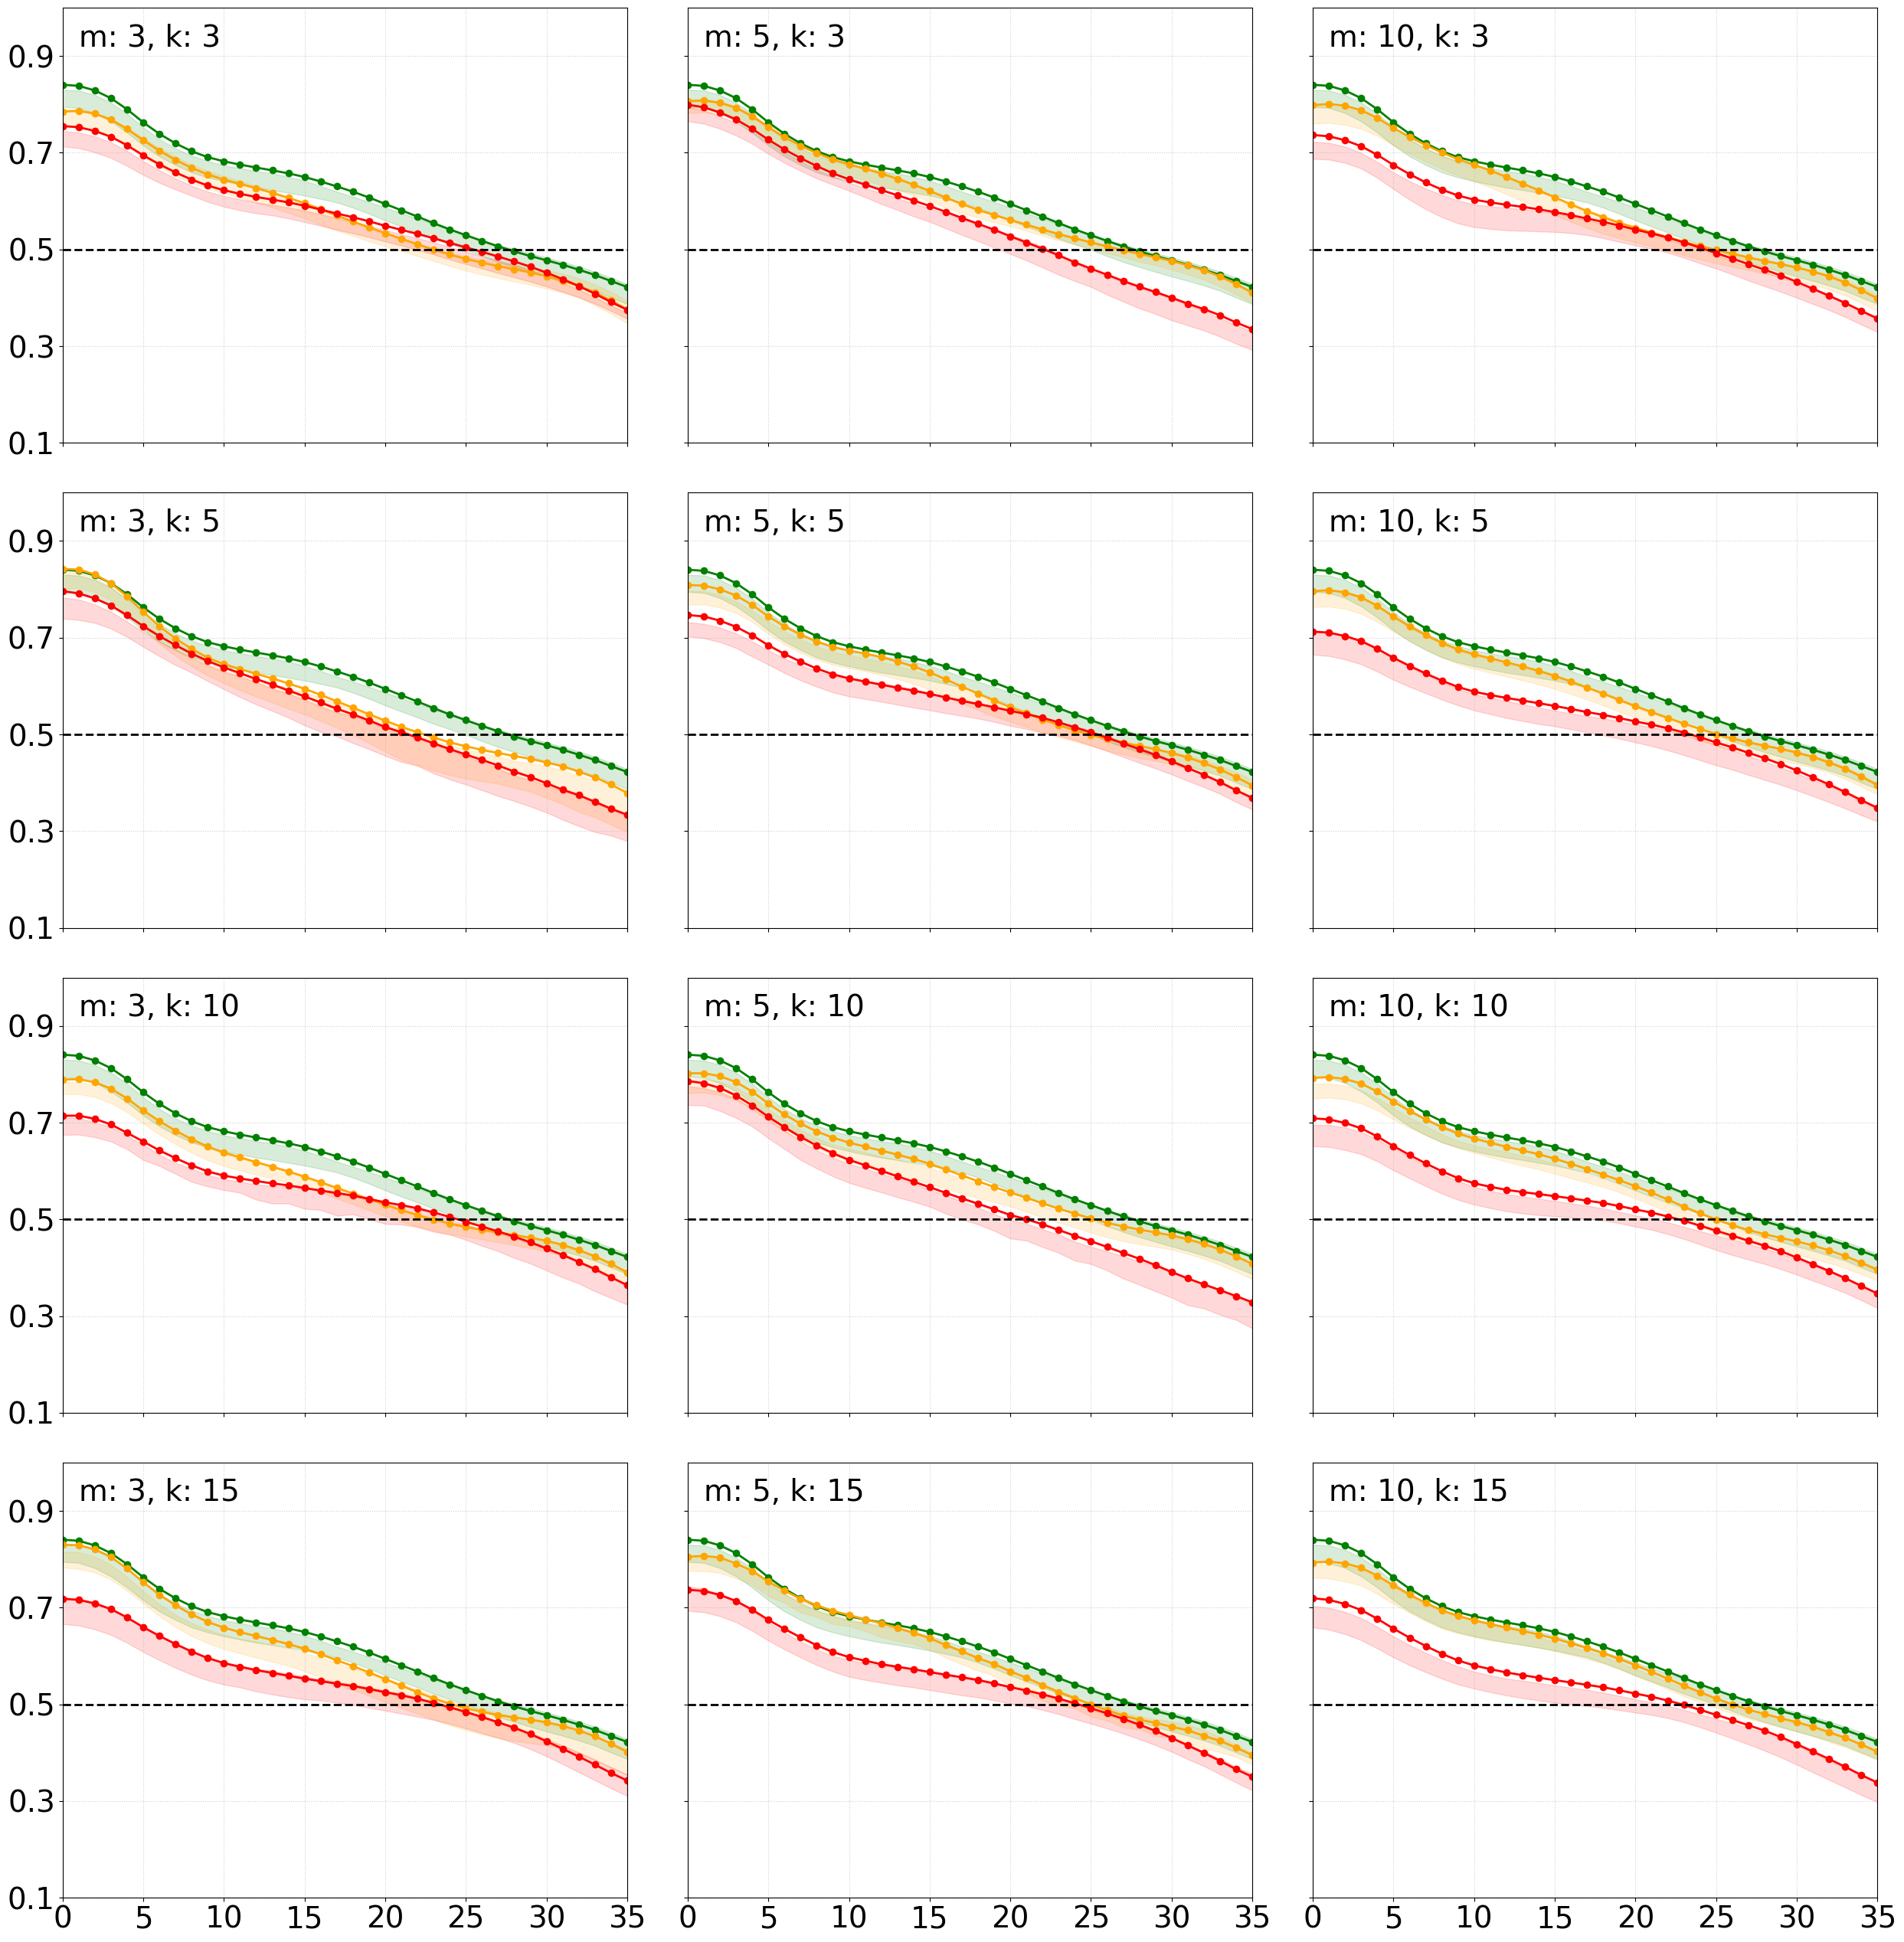


Saved single 4x3 figure to:
/scratch/users/linyao/ML4MJO/scripts/outputs/Figs/FigS_cutoffs/plot_bcc_cutoff_era5_olr_UNet_A_ROMI_test_grid4x3.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================================================================
# 1. Configuration & Setup
# ======================================================================
dataflg = os.environ.get("dataflg", "era5").lower()
input_var_name = os.environ.get("input_var", "olr")
model_name = os.environ.get("model_name", "UNet_A")
output_var_name = os.environ.get("output_var", "ROMI")  # single output_var

trial_tag = "t1"
period_name = "test"

# Cut-off sweep (matches a3_bcc_cutoff.sh)
m_values = [3, 5, 10]      # -> 3 columns
wnx_values = [2, 4, 9, 14] # -> 4 rows

COLOR_FLTANO = 'green'
COLOR_ALL    = 'orange'
COLOR_RESI   = 'red'

metrics_base_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/metrics")
save_dir = Path("/scratch/users/linyao/ML4MJO/scripts/outputs/Figs") / "FigS_cutoffs"
save_dir.mkdir(parents=True, exist_ok=True)


# ======================================================================
# 2. Helper: Load multi_lead BCC metrics for a given exp flag
# ======================================================================
def load_multi_lead_bcc(expflg):
    exp_name = f"{dataflg}_{input_var_name}_{model_name}_{output_var_name}_{expflg}"
    data_path = metrics_base_dir / exp_name / f"metrics_{exp_name}_{trial_tag}_{period_name}.npz"
    if not data_path.exists():
        print(f"     [Warning] Missing data for {exp_name}. Skipping line.")
        return None
    data = np.load(data_path)
    lead_max = int(data['lead'])
    leads = np.arange(0, lead_max + 1)
    return leads, data['ens_bcc'], data['ind_bcc']


def plot_experiment(ax, result, color, label):
    if result is None:
        return
    leads, ens_bcc, ind_bcc = result
    bcc_min = np.min(ind_bcc, axis=0)
    bcc_max = np.max(ind_bcc, axis=0)
    ax.fill_between(leads, bcc_min, bcc_max, color=color, alpha=0.15)
    ax.plot(leads, ens_bcc, '-o', color=color, linewidth=2, label=label)


# ======================================================================
# 3. ONE figure with 4 rows x 3 columns (all cut-offs)
# ======================================================================
print("\n=== GENERATING SINGLE 4x3 BCC CUT-OFF FIGURE ===")

plt.rcParams['font.size'] = 28

n_rows = len(wnx_values)  # 4
n_cols = len(m_values)    # 3

# fltano120 is the same across panels; load once
fltano_result = load_multi_lead_bcc('fltano120')

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(8.5 * n_cols, 6.5 * n_rows),
                         sharex=True, sharey=True)

for r, wnx in enumerate(wnx_values):
    for c, m in enumerate(m_values):
        ax = axes[r, c]

        all_expflg  = f"unscaled_m{m}all_wnx{wnx}all"
        resi_expflg = f"unscaled_m{m}resi_wnx{wnx}resi"

        all_result  = load_multi_lead_bcc(all_expflg)
        resi_result = load_multi_lead_bcc(resi_expflg)

        plot_experiment(ax, fltano_result, COLOR_FLTANO, 'fltano120')
        plot_experiment(ax, all_result,    COLOR_ALL,    f'm{m}all_wnx{wnx}all')
        plot_experiment(ax, resi_result,   COLOR_RESI,   f'm{m}resi_wnx{wnx}resi')

        ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2)
        ax.set_xticks(np.arange(0, 41, 5))
        ax.set_xlim(0, 35)
        ax.set_ylim(0.1, 1.0)
        ax.set_yticks(np.arange(0.1, 1.1, 0.2))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.text(1, 0.92, f'm: {m}, k: {wnx + 1}')
        ax.grid(True, linestyle=':', alpha=0.6)

fig.tight_layout()
save_path = save_dir / (
    f"plot_bcc_cutoff_{dataflg}_{input_var_name}_{model_name}_"
    f"{output_var_name}_{period_name}_grid4x3.png"
)
fig.savefig(save_path, dpi=300)
plt.show()
plt.close(fig)

print(f"\nSaved single 4x3 figure to:\n{save_path}")
